In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load data
# -----------------------------

deliveries = pd.read_csv("data/raw/deliveries.csv")
routes = pd.read_csv("data/raw/routes.csv")

print("Original deliveries rows:", len(deliveries))
print("Routes rows:", len(routes))


# -----------------------------
# 2. Confirm numeric types
# -----------------------------

deliveries["promised_days"] = pd.to_numeric(
    deliveries["promised_days"]
)

deliveries["actual_days"] = pd.to_numeric(
    deliveries["actual_days"]
)


# -----------------------------
# 3. Remove exact duplicate
# -----------------------------

deliveries = deliveries.drop_duplicates()

print("Clean deliveries rows:", len(deliveries))


# -----------------------------
# 4. Merge with routes
# -----------------------------

df = deliveries.merge(
    routes,
    on="route_id",
    how="left"
)


# -----------------------------
# 5. Validation
# -----------------------------

assert len(df) == 12
assert df["service_type"].isna().sum() == 0

print("Validation passed.")
print("Rows:", len(df))
print("Unmatched service_type:", df["service_type"].isna().sum())


# -----------------------------
# 6. Calculate delay_days
# -----------------------------

df["delay_days"] = (
    df["actual_days"] - df["promised_days"]
).clip(lower=0)


# -----------------------------
# 7. Delay incidence
# -----------------------------

df["is_delayed"] = (
    df["actual_days"] > df["promised_days"]
)


# -----------------------------
# 8. Service type summary
# -----------------------------

summary = (
    df.groupby("service_type")
    .agg(
        total_delay_days=("delay_days", "sum"),
        total_records=("delay_days", "count"),
        delayed_records=("is_delayed", "sum")
    )
    .reset_index()
)

summary["delay_incidence_rate"] = (
    summary["delayed_records"]
    / summary["total_records"]
)

summary["delay_incidence_rate"] *= 100

print("\nService Type Summary:")
print(summary)


# -----------------------------
# 9. Route with greatest delay
# -----------------------------

route_summary = (
    df.groupby(["route_id", "route"])["delay_days"]
    .sum()
    .reset_index()
    .sort_values("delay_days", ascending=False)
)

top_route = route_summary.iloc[0]

overall_delay = df["delay_days"].sum()

top_route_share = (
    top_route["delay_days"] / overall_delay * 100
)

print("\nTop Route:")
print(top_route)

print(
    f"Top route delay share: {top_route_share:.2f}%"
)


# -----------------------------
# 10. Monthly summary
# -----------------------------

month_order = ["Jan", "Feb", "Mar"]

monthly = (
    df.groupby("month")["delay_days"]
    .sum()
    .reindex(month_order)
)

print("\nMonthly Delay:")
print(monthly)


# -----------------------------
# 11. Chart
# -----------------------------

plt.figure(figsize=(8, 5))

monthly.plot(kind="bar")

plt.title("Monthly Total Delivery Delay")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")

plt.tight_layout()

plt.savefig(
    "outputs/python_chart.png",
    dpi=150
)

plt.close()


# -----------------------------
# 12. Export clean data
# -----------------------------

df.to_csv(
    "outputs/clean_data.csv",
    index=False
)


# -----------------------------
# 13. Export summary
# -----------------------------

summary.to_csv(
    "outputs/python_summary.csv",
    index=False
)

print("\nFiles exported successfully.")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

deliveries = pd.read_csv("deliveries.csv")
routes = pd.read_csv("routes.csv")

print("Deliveries:",deliveries.head() )
print("\nroutes:",routes.head() )


Deliveries:    record_id month route_id      hub  promised_days  actual_days
0          1   Jan       R1   Mumbai              2            2
1          2   Jan       R2  Chennai              3            4
2          3   Jan       R3    Delhi              5            8
3          4   Jan       R4   Mumbai              6           10
4          5   Feb       R1  Chennai              2            5

routes:   route_id            route service_type
0       R1       Metro Link      Express
1       R2        City Dash      Express
2       R3  Highway Freight     Standard
3       R4     Rural Feeder     Standard


In [3]:
# --- 2. Confirm numeric types

deliveries["promised_days"] = pd.to_numeric(
    deliveries["promised_days"]
)

deliveries["actual_days"] = pd.to_numeric(
    deliveries["actual_days"]
)

In [4]:
# --- 3. Remove exact duplicate

deliveries = deliveries.drop_duplicates()

print("Clean deliveries rows:", len(deliveries))

Clean deliveries rows: 12


In [6]:
# --- 4. Merge with routes
df = deliveries.merge(
   
    routes,
    on="route_id",
    how="left"
)

df

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


In [7]:
# --- 5. Validation

assert len(df) == 12
assert df["service_type"].isna().sum() == 0

print("Validation passed.")
print("Rows:", len(df))
print("Unmatched service_type:", df["service_type"].isna().sum())

Validation passed.
Rows: 12
Unmatched service_type: 0


In [8]:

# --- 6. Calculate delay_days

df["delay_days"] = (
    df["actual_days"] - df["promised_days"]
).clip(lower=0)

In [9]:

# --- 7. Delay incidence


df["is_delayed"] = (
    df["actual_days"] > df["promised_days"]
)

In [10]:
# --- 8. Service type summary

summary = (
    df.groupby("service_type")
    .agg(
        total_delay_days=("delay_days", "sum"),
        total_records=("delay_days", "count"),
        delayed_records=("is_delayed", "sum")
    )
    .reset_index()
)

summary["delay_incidence_rate"] = (
    summary["delayed_records"]
    / summary["total_records"]
)

summary["delay_incidence_rate"] *= 100

print("\nService Type Summary:")
print(summary)


Service Type Summary:
  service_type  total_delay_days  total_records  delayed_records  \
0      Express                12              6                4   
1     Standard                22              6                5   

   delay_incidence_rate  
0             66.666667  
1             83.333333  


In [11]:
# --- 9. Route with greatest delay


route_summary = (
    df.groupby(["route_id", "route"])["delay_days"]
    .sum()
    .reset_index()
    .sort_values("delay_days", ascending=False)
)

top_route = route_summary.iloc[0]

overall_delay = df["delay_days"].sum()

top_route_share = (
    top_route["delay_days"] / overall_delay * 100
)

print("\nTop Route:")
print(top_route)

print(
    f"Top route delay share: {top_route_share:.2f}%"
)



Top Route:
route_id                R4
route         Rural Feeder
delay_days              14
Name: 3, dtype: object
Top route delay share: 41.18%


In [12]:
# --- 10. Monthly summary


month_order = ["Jan", "Feb", "Mar"]

monthly = (
    df.groupby("month")["delay_days"]
    .sum()
    .reindex(month_order)
)

print("\nMonthly Delay:")
print(monthly)


Monthly Delay:
month
Jan     8
Feb     9
Mar    17
Name: delay_days, dtype: int64


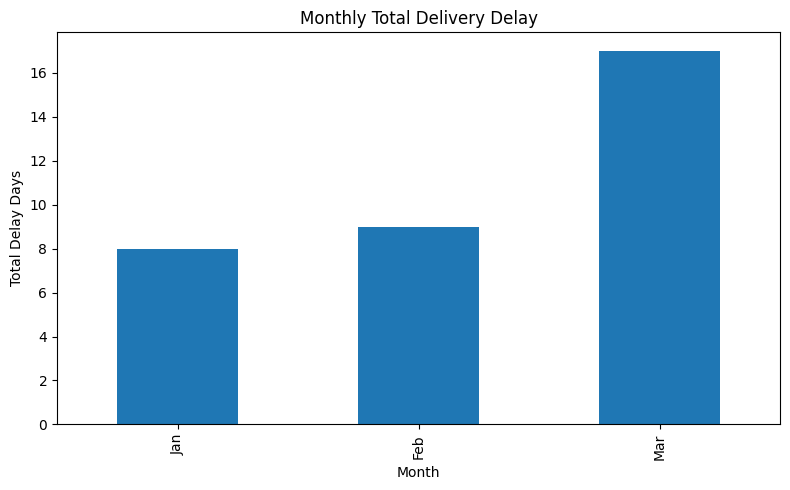

In [20]:
# --- 11. Chart


plt.figure(figsize=(8, 5))

monthly.plot(kind="bar")

plt.title("Monthly Total Delivery Delay")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Jeel\OneDrive\brocode\OneDrive\Desktop\Data_Analysis_SET_A_10861\output\python_chart.png",
    dpi=150
)

plt.show()
plt.close()

In [21]:

# --- 12. Export clean data


df.to_csv(
    r"C:\Users\Jeel\OneDrive\brocode\OneDrive\Desktop\Data_Analysis_SET_A_10861\output\clean_data.csv",
    index=False
)



# --- 13. Export summary


summary.to_csv(
    r"C:\Users\Jeel\OneDrive\brocode\OneDrive\Desktop\Data_Analysis_SET_A_10861\output\python_summary.csv",
    index=False
)

print("\nFiles exported successfully.")


Files exported successfully.
